<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/TEG011.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

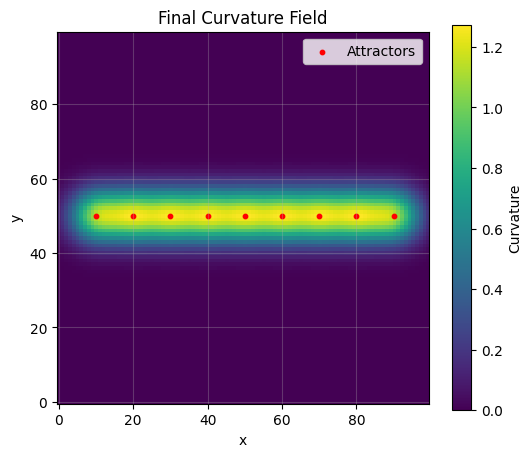

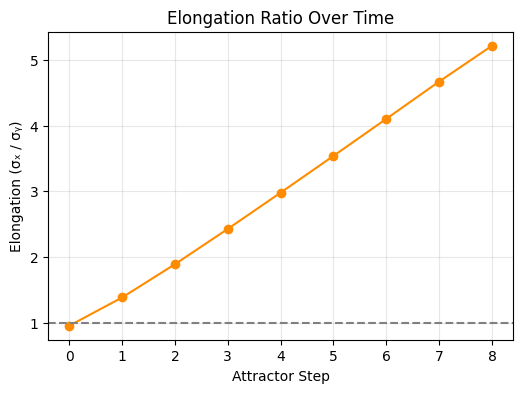

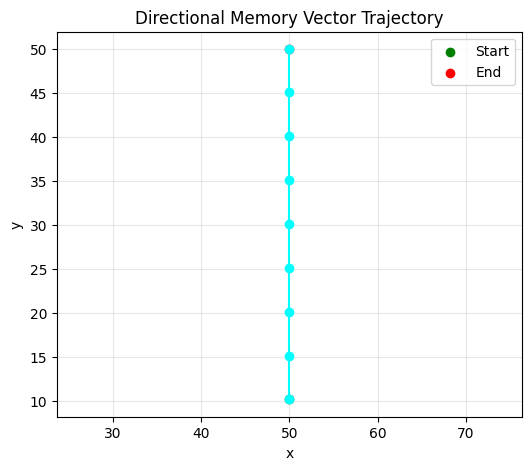

In [2]:
# TEG011A — Sequential Attractor Memory
# Simulates cumulative curvature and directional memory from sequential attractors

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import center_of_mass

# === Parameters ===
grid_size = 100
curvature = np.zeros((grid_size, grid_size))
A = 1.0        # Amplitude of each attractor
sigma = 5      # Width of Gaussian bump
y_center = 50  # Fixed y-position for attractors
x_positions = np.arange(10, 91, 10)  # Attractors at x = 10, 20, ..., 90

elongation_history = []
memory_vector = []

# === Coordinate Grid ===
X, Y = np.meshgrid(np.arange(grid_size), np.arange(grid_size))

# === Weighted standard deviation ===
def weighted_std(values, weights):
    average = np.average(values, weights=weights)
    variance = np.average((values - average)**2, weights=weights)
    return np.sqrt(variance)

# === Drop Attractors Sequentially ===
for x0 in x_positions:
    dx = X - x0
    dy = Y - y_center
    gaussian = A * np.exp(-(dx**2 + dy**2) / (2 * sigma**2))
    curvature += gaussian

    # Elongation: ratio of std dev along x vs y
    x_proj = np.sum(curvature, axis=0)
    y_proj = np.sum(curvature, axis=1)
    x_vals = np.arange(grid_size)
    y_vals = np.arange(grid_size)

    elong_x = weighted_std(x_vals, x_proj)
    elong_y = weighted_std(y_vals, y_proj)
    elongation = elong_x / (elong_y + 1e-8)
    elongation_history.append(elongation)

    # Memory vector: center of mass of curvature
    com = center_of_mass(curvature)
    memory_vector.append(com)

# === Plot 1: Final Curvature Field ===
plt.figure(figsize=(6,5))
plt.imshow(curvature, cmap='viridis', origin='lower')
plt.colorbar(label='Curvature')
plt.title('Final Curvature Field')
plt.xlabel('x'); plt.ylabel('y')
plt.scatter(x_positions, [y_center]*len(x_positions), color='red', s=10, label='Attractors')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# === Plot 2: Elongation Over Time ===
plt.figure(figsize=(6,4))
plt.plot(elongation_history, marker='o', color='darkorange')
plt.title('Elongation Ratio Over Time')
plt.xlabel('Attractor Step'); plt.ylabel('Elongation (σₓ / σᵧ)')
plt.grid(alpha=0.3)
plt.axhline(1.0, color='gray', linestyle='--')
plt.show()

# === Plot 3: Memory Vector Trajectory ===
memory_vector = np.array(memory_vector)
plt.figure(figsize=(6,5))
plt.plot(memory_vector[:,0], memory_vector[:,1], marker='o', color='cyan')
plt.title('Directional Memory Vector Trajectory')
plt.xlabel('x'); plt.ylabel('y')
plt.grid(alpha=0.3)
plt.scatter(memory_vector[0,0], memory_vector[0,1], color='green', label='Start')
plt.scatter(memory_vector[-1,0], memory_vector[-1,1], color='red', label='End')
plt.legend()
plt.axis('equal')
plt.show()
